In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import json
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
from pathlib import Path

class IncorrectResultsAnalyzer:
    def __init__(self, results_dir="training_results", local_images_dir="../../tests/generated_samples"):
        self.results_dir = results_dir
        self.local_images_dir = local_images_dir
        self.current_index = 0
        self.df = None
        self.filtered_df = None
        
    def load_latest_results(self):
        """Load the most recent incorrect results CSV file"""
        results_path = Path(self.results_dir)
        
        # Find the most recent run directory
        if not results_path.exists():
            print(f"Results directory {results_path} not found")
            return None
            
        run_dirs = [d for d in results_path.iterdir() if d.is_dir() and d.name.startswith("run_")]
        if not run_dirs:
            print("No run directories found")
            return None
            
        latest_run = max(run_dirs, key=lambda x: x.stat().st_mtime)
        csv_file = latest_run / "incorrect_results.csv"
        
        if not csv_file.exists():
            print(f"No incorrect_results.csv found in {latest_run}")
            return None
            
        print(f"Loading results from: {csv_file}")
        self.df = pd.read_csv(csv_file)
        
        # Filter only incorrect results (where correct == False)
        self.filtered_df = self.df[self.df['correct'] == False].reset_index(drop=True)
        
        print(f"Total results: {len(self.df)}")
        print(f"Incorrect results: {len(self.filtered_df)}")
        
        return self.filtered_df
    
    def translate_image_path(self, mounted_path):
        """Translate mounted storage path to local path"""
        if pd.isna(mounted_path):
            return None
            
        # Convert from mounted path to local path
        # /opt/nuclio/shared_storage/generated_samples/... -> ../../tests/generated_samples/...
        if "/opt/nuclio/shared_storage/generated_samples/" in mounted_path:
            relative_path = mounted_path.replace("/opt/nuclio/shared_storage/generated_samples/", "")
            local_path = os.path.join(self.local_images_dir, relative_path)
            return local_path
        
        # If path doesn't match expected pattern, return as-is
        return mounted_path
    
    def get_predicted_class(self, predicted_value):
        """Get predicted class from the predicted column"""
        if pd.isna(predicted_value):
            return "not classified"
        return predicted_value
    
    def display_current_image(self):
        """Display current image with classification info"""
        if self.filtered_df is None or len(self.filtered_df) == 0:
            print("No data loaded")
            return
            
        if self.current_index >= len(self.filtered_df):
            print("No more images")
            return
            
        row = self.filtered_df.iloc[self.current_index]
        
        # Clear previous output
        clear_output(wait=True)
        
        # Display progress
        print(f"Image {self.current_index + 1} of {len(self.filtered_df)}")
        print("=" * 50)
        
        # Load and display image
        original_path = row['image_path']
        image_path = self.translate_image_path(original_path)
        
        if image_path and os.path.exists(image_path):
            img = Image.open(image_path)
            
            fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image: {os.path.basename(image_path)}")
            ax.axis('off')
            plt.show()
        else:
            print(f"Image not found at: {image_path}")
            print(f"Original path was: {original_path}")
        
        # Display classification info
        expected_class = row['expected']
        predicted_class = self.get_predicted_class(row['predicted'])
        
        print(f"Expected Class: {expected_class}")
        print(f"Predicted Class: {predicted_class}")
        print(f"Status: {row.get('status', 'unknown')}")
        
        if not pd.isna(row['classification_results']) and row['classification_results'] != "":
            try:
                results = json.loads(row['classification_results'])
                print("\nClassification Details:")
                for i, result in enumerate(results[:3]):  # Show top 3 results
                    concept_id = result.get('concept_id', 'unknown')
                    similarity = result.get('similarity', 0)
                    print(f"  {i+1}. Concept: {concept_id}, Similarity: {similarity:.3f}")
            except:
                print("Could not parse classification results")
        
        print(f"\nLocal Path: {image_path}")
        print(f"Original Path: {original_path}")
        
        # Display control buttons
        self.display_controls()
    
    def display_controls(self):
        """Display interactive control buttons"""
        next_btn = widgets.Button(description="Next Image", button_style='info')
        prev_btn = widgets.Button(description="Previous Image", button_style='info')
        delete_btn = widgets.Button(description="Delete Image", button_style='danger')
        jump_input = widgets.IntText(value=self.current_index + 1, description="Go to:", min=1, max=len(self.filtered_df))
        jump_btn = widgets.Button(description="Jump", button_style='success')
        
        def on_next_click(b):
            if self.current_index < len(self.filtered_df) - 1:
                self.current_index += 1
                self.display_current_image()
            else:
                print("Already at the last image")
        
        def on_prev_click(b):
            if self.current_index > 0:
                self.current_index -= 1
                self.display_current_image()
            else:
                print("Already at the first image")
        
        def on_delete_click(b):
            if self.filtered_df is None or len(self.filtered_df) == 0:
                return
                
            row = self.filtered_df.iloc[self.current_index]
            original_path = row['image_path']
            image_path = self.translate_image_path(original_path)
            
            if image_path and os.path.exists(image_path):
                try:
                    os.remove(image_path)
                    print(f"Deleted: {image_path}")
                    
                    # Remove from dataframe
                    self.filtered_df = self.filtered_df.drop(self.filtered_df.index[self.current_index]).reset_index(drop=True)
                    
                    # Adjust current index if needed
                    if self.current_index >= len(self.filtered_df):
                        self.current_index = len(self.filtered_df) - 1
                    
                    if len(self.filtered_df) > 0:
                        self.display_current_image()
                    else:
                        print("No more images to display")
                        
                except Exception as e:
                    print(f"Error deleting file: {e}")
            else:
                print(f"File not found: {image_path}")
        
        def on_jump_click(b):
            target_index = jump_input.value - 1
            if 0 <= target_index < len(self.filtered_df):
                self.current_index = target_index
                self.display_current_image()
            else:
                print(f"Invalid index. Must be between 1 and {len(self.filtered_df)}")
        
        next_btn.on_click(on_next_click)
        prev_btn.on_click(on_prev_click)
        delete_btn.on_click(on_delete_click)
        jump_btn.on_click(on_jump_click)
        
        navigation_box = widgets.HBox([prev_btn, next_btn])
        jump_box = widgets.HBox([jump_input, jump_btn])
        controls_box = widgets.VBox([navigation_box, jump_box, delete_btn])
        
        display(controls_box)
    
    def get_statistics(self):
        """Display statistics about incorrect classifications"""
        if self.filtered_df is None:
            print("No data loaded")
            return
            
        print("Incorrect Classification Statistics:")
        print("=" * 40)
        
        # Count by expected class
        expected_counts = self.filtered_df['expected'].value_counts().sort_index()
        print("\nIncorrect predictions by expected class:")
        for class_num, count in expected_counts.items():
            print(f"  Class {class_num}: {count} incorrect")
        
        # Count by predicted class
        predicted_counts = self.filtered_df['predicted'].value_counts()
        
        print("\nMost common incorrect predictions:")
        for pred_class, count in predicted_counts.head(10).items():
            print(f"  Predicted as {pred_class}: {count} times")
        
        # Confusion pairs
        print("\nMost common confusion pairs (expected -> predicted):")
        confusion_pairs = self.filtered_df.groupby(['expected', 'predicted']).size().sort_values(ascending=False)
        for (expected, predicted), count in confusion_pairs.head(10).items():
            print(f"  {expected} -> {predicted}: {count} times")
    
    def start_analysis(self):
        """Start the interactive analysis"""
        if self.load_latest_results() is None:
            return
            
        if len(self.filtered_df) == 0:
            print("No incorrect results found!")
            return
            
        self.get_statistics()
        print("\n" + "="*50)
        print("Starting interactive analysis...")
        print("Use the buttons below to navigate through incorrect results")
        print("="*50)
        
        self.display_current_image()

# Initialize the analyzer
analyzer = IncorrectResultsAnalyzer()
print("Incorrect Results Analyzer loaded!")
print("Run: analyzer.start_analysis() to begin")
print(f"Local images directory: {analyzer.local_images_dir}")
print(f"Results directory: {analyzer.results_dir}")


Incorrect Results Analyzer loaded!
Run: analyzer.start_analysis() to begin
Local images directory: ../../tests/generated_samples
Results directory: training_results


# Incorrect Results Analyzer

This notebook provides an interactive interface to analyze incorrectly classified images from the NaturalAGI training results.

## Features:
- ✅ **Image Display**: Shows incorrectly classified images
- ✅ **Expected vs Predicted**: Clear comparison of expected and predicted classes
- ✅ **Navigation**: Next/Previous image buttons
- ✅ **Delete Function**: Remove images from the file system
- ✅ **Jump to Image**: Navigate directly to a specific image number
- ✅ **Statistics**: Overview of incorrect classification patterns
- ✅ **Auto-load Latest**: Automatically loads the most recent training results
- ✅ **Path Translation**: Automatically converts mounted storage paths to local paths

## Usage:
1. Run the cell above to load the analyzer
2. Run `analyzer.start_analysis()` to begin interactive analysis
3. Use the buttons to navigate through images:
   - **Previous/Next**: Navigate through images
   - **Delete Image**: Remove the current image from disk (⚠️ **Permanent**)
   - **Jump**: Go directly to a specific image number

## Quick Commands:
```python
# Start analysis
analyzer.start_analysis()

# View statistics only
analyzer.load_latest_results()
analyzer.get_statistics()

# Load specific results directory
analyzer = IncorrectResultsAnalyzer("path/to/results")
analyzer.start_analysis()
```


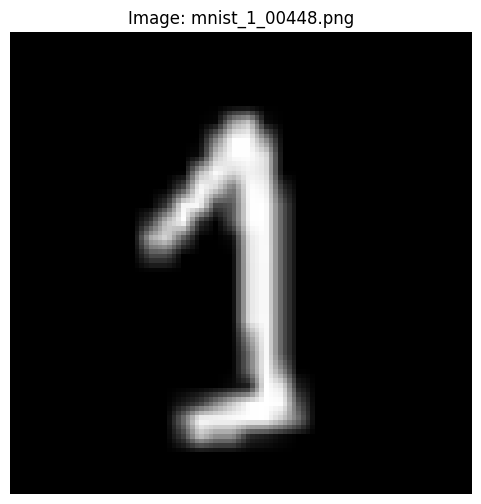

In [ ]:
# Quick Start - Run this cell to begin analyzing incorrect results
analyzer.start_analysis()
